<a href="https://colab.research.google.com/github/Patro331/blood-smear-sickle-cell-classification/blob/main/notebooks/07_ml_vs_dl_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Blood Smear Sickle Cell Classification
## MSB7215: Machine Learning in Biomedicine
### Notebook 07: Classical ML vs Deep Learning Comparison

**Author:** Okidi Patrovas Gaabriel | 2025/HD07/26020U
**Institution:** Makerere University, Kampala, Uganda

## Overview

This notebook compares the performance of classical machine learning
models developed in this project against deep learning models from
a separate study on the same dataset.

The deep learning results referenced here were obtained in a prior
study: "Deep Learning for Automated Sickle Cell Detection in
Peripheral Blood Smears" (Okidi Patrovas Gaabriel, 2026), available
at https://github.com/Patro331/sickle-cell-detection

The deep learning results are reproduced here for comparative
analysis only and were not produced as part of this work. This
comparison addresses the research question: does classical machine
learning with HOG features produce competitive results compared
to deep learning for sickle cell detection?

Models compared:
- Classical ML: SVM and Random Forest (this project)
- Deep Learning: Baseline CNN, EfficientNet-B0, ResNet-50 (prior study)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("All libraries imported successfully")

All libraries imported successfully


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Compile All Results

We compile results from both studies into a single dataframe.
Classical ML results are loaded from saved metrics in this project.
Deep learning results are documented values from the prior study
and are clearly labelled as such.

In [3]:
# All results compiled into one dataframe
results = {
    'Model': [
        'SVM (Classical ML)',
        'Random Forest (Classical ML)',
        'Baseline CNN (Deep Learning)*',
        'EfficientNet-B0 (Deep Learning)*',
        'ResNet-50 (Deep Learning)*'
    ],
    'Type': [
        'Classical ML',
        'Classical ML',
        'Deep Learning',
        'Deep Learning',
        'Deep Learning'
    ],
    'Features': [
        'HOG (8100)',
        'HOG (8100)',
        'Raw pixels',
        'Raw pixels',
        'Raw pixels'
    ],
    'Test Accuracy (%)': [91.98, 87.17, 87.86, 96.43, 98.57],
    'AUC-ROC':           [0.9651, 0.9396, 0.9588, 0.9951, 0.9973],
    'F1 Score':          [0.9133, 0.8723, 0.8759, 0.9600, 0.9841],
    'Sensitivity (%)':   [92.94, 96.47, 95.24, 95.24, 98.41],
    'Specificity (%)':   [91.18, 79.41, 81.82, 97.40, 98.70],
    'Errors':            [15, 24, 17, 5, 2],
    'Test Set Size':     [187, 187, 140, 140, 140]
}

df = pd.DataFrame(results)
df.set_index('Model', inplace=True)

print("Complete Results Table:")
print(df.to_string())
print("\n* Deep learning results from: Okidi Patrovas Gaabriel (2026).")
print("  Deep Learning for Automated Sickle Cell Detection in Peripheral")
print("  Blood Smears. https://github.com/Patro331/sickle-cell-detection")

Complete Results Table:
                                           Type    Features  Test Accuracy (%)  AUC-ROC  F1 Score  Sensitivity (%)  Specificity (%)  Errors  Test Set Size
Model                                                                                                                                                     
SVM (Classical ML)                 Classical ML  HOG (8100)              91.98   0.9651    0.9133            92.94            91.18      15            187
Random Forest (Classical ML)       Classical ML  HOG (8100)              87.17   0.9396    0.8723            96.47            79.41      24            187
Baseline CNN (Deep Learning)*     Deep Learning  Raw pixels              87.86   0.9588    0.8759            95.24            81.82      17            140
EfficientNet-B0 (Deep Learning)*  Deep Learning  Raw pixels              96.43   0.9951    0.9600            95.24            97.40       5            140
ResNet-50 (Deep Learning)*        Deep Learnin

### Observations

The combined results table shows all five models across both studies.
The classical ML models used a 187-sample test set while the deep
learning models used a 140-sample test set, both drawn from the
same 933-image dataset using different split ratios. This difference
in test set size should be kept in mind when comparing absolute
error counts, though percentage-based metrics such as accuracy and
AUC-ROC remain directly comparable.

## 2. Visual Comparison

We plot the key metrics side by side to clearly show how classical
ML and deep learning models compare on this task.

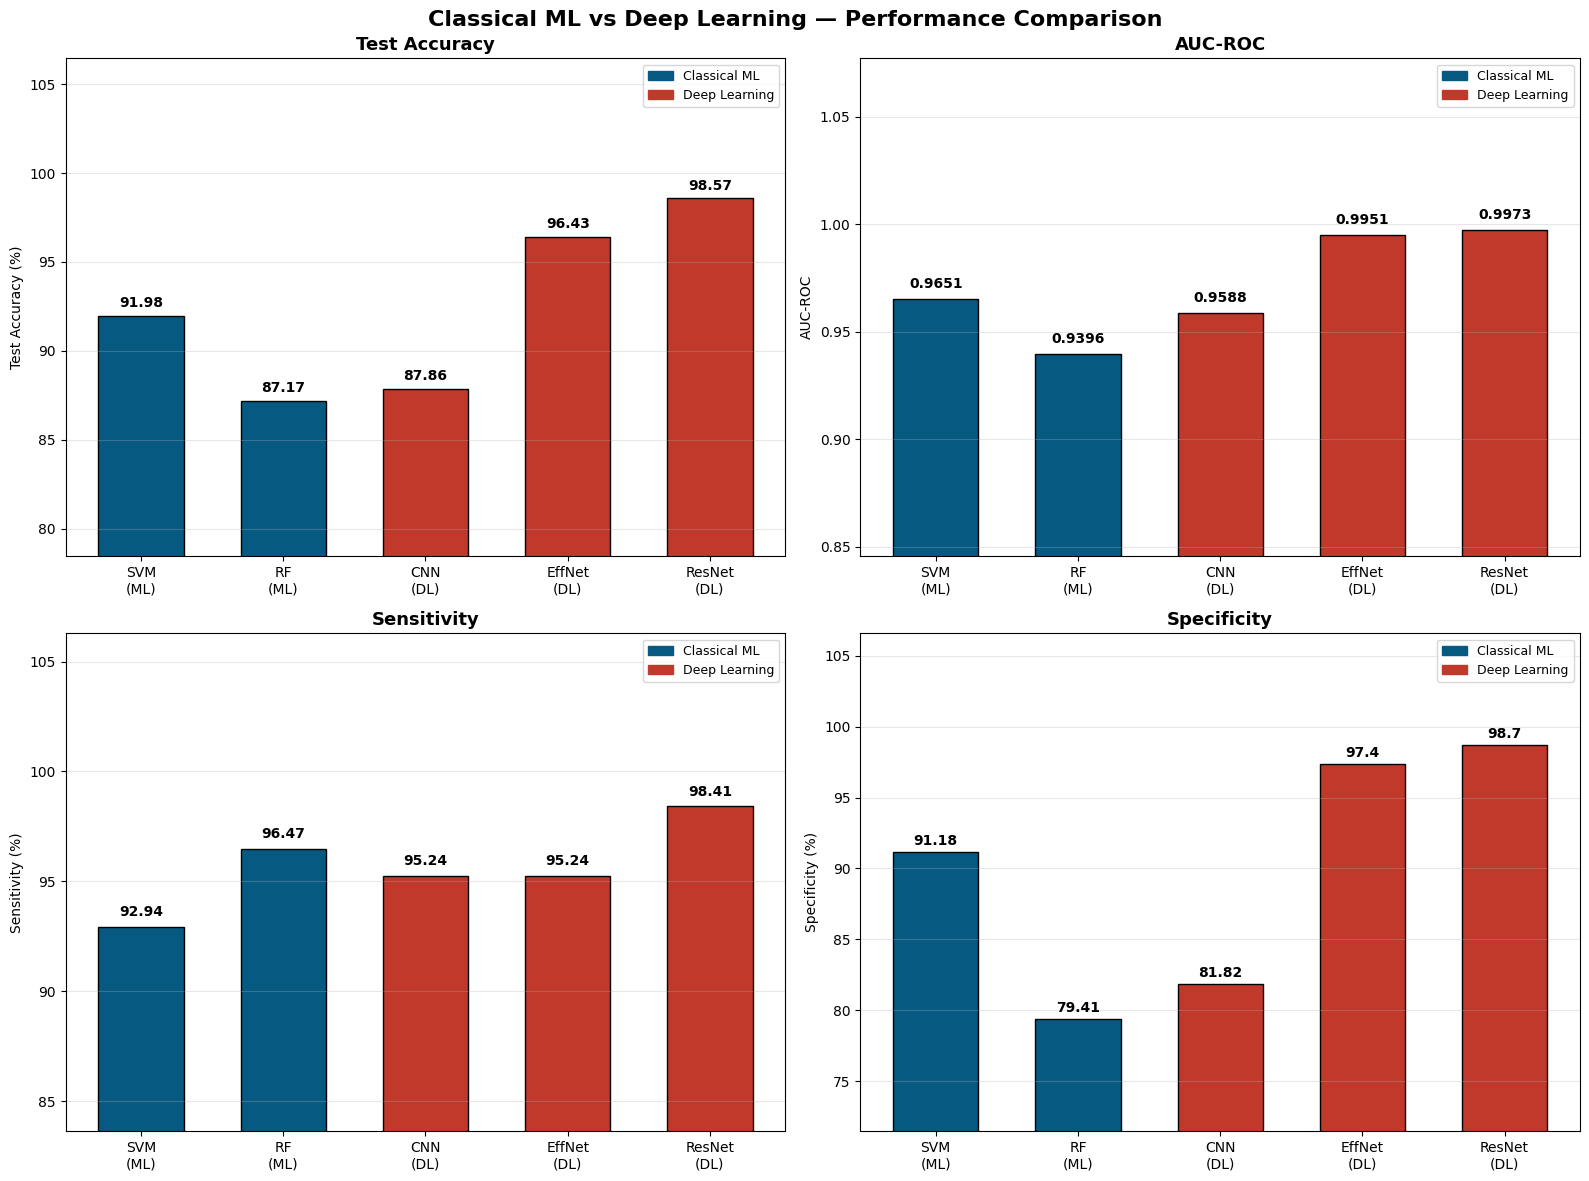

Comparison plot saved


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Classical ML vs Deep Learning — Performance Comparison',
             fontsize=16, fontweight='bold')

models      = df.index.tolist()
colors      = ['#065A82', '#1C7293', '#E67E22', '#8E44AD', '#C0392B']
ml_color    = '#065A82'
dl_color    = '#C0392B'
type_colors = [ml_color if t == 'Classical ML' else dl_color
               for t in df['Type']]

metrics = [
    ('Test Accuracy (%)', 'Test Accuracy'),
    ('AUC-ROC',           'AUC-ROC'),
    ('Sensitivity (%)',   'Sensitivity'),
    ('Specificity (%)',   'Specificity')
]

short_names = ['SVM\n(ML)', 'RF\n(ML)', 'CNN\n(DL)', 'EffNet\n(DL)', 'ResNet\n(DL)']

for idx, (col, title) in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    bars = ax.bar(short_names, df[col].values,
                  color=type_colors, edgecolor='black', width=0.6)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_ylabel(col)
    ax.set_ylim(min(df[col].values) * 0.9, max(df[col].values) * 1.08)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, df[col].values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(df[col].values) * 0.005,
                str(val), ha='center', fontsize=10, fontweight='bold')

    ml_patch = mpatches.Patch(color=ml_color, label='Classical ML')
    dl_patch = mpatches.Patch(color=dl_color, label='Deep Learning')
    ax.legend(handles=[ml_patch, dl_patch], fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sickle-cell-detection/figures/ml_vs_dl_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Comparison plot saved")

### Observations

The bar charts show a clear pattern across all four metrics. Deep
learning models generally outperform classical ML models, with
ResNet-50 achieving the highest scores across accuracy, AUC-ROC,
and specificity. However the gap is not as large as might be
expected — SVM achieves 91.98% accuracy which is competitive with
EfficientNet-B0 at 96.43%, and both are well above the deep
learning baseline CNN at 87.86%.

The sensitivity plot is particularly interesting. Random Forest
achieves 96.47% sensitivity, outperforming both the baseline CNN
and EfficientNet-B0. This shows that classical ML is not simply
inferior to deep learning in all respects — for clinical screening
where sensitivity is the priority, Random Forest is a viable
alternative that requires far less computational resources.

The specificity plot shows the clearest advantage of deep learning,
with EfficientNet-B0 and ResNet-50 both above 97% compared to
SVM at 91.18% and Random Forest at 79.41%.

## 3. Discussion — Why Deep Learning Outperforms Classical ML

We discuss the key reasons behind the performance difference
between the two approaches.

WHY DEEP LEARNING OUTPERFORMS CLASSICAL ML ON THIS TASK
---------------------------------------------------------

1. FEATURE LEARNING vs HAND-CRAFTED FEATURES
   Classical ML relies on HOG features, which capture gradient
   orientations in fixed 8x8 pixel cells. These are hand-crafted
   and may miss subtle morphological differences between sickle
   and normal cells that are not captured by gradient orientation.
   
   Deep learning learns features directly from raw pixel data
   through multiple convolutional layers, automatically discovering
   the most discriminative visual patterns without human design.

2. TRANSFER LEARNING ADVANTAGE
   EfficientNet-B0 and ResNet-50 were pretrained on 1.2 million
   ImageNet images. This gives them rich visual feature
   representations that transfer effectively to blood smear
   microscopy, even with only 933 training images.
   
   Classical ML has no equivalent of transfer learning — it must
   learn all discriminative patterns from the small training set.

3. SPATIAL HIERARCHY
   Deep learning models learn hierarchical features — edges in
   early layers, shapes in middle layers, and high-level cell
   morphology in deeper layers. HOG captures only local gradient
   patterns without this hierarchical understanding.

4. WHERE CLASSICAL ML REMAINS COMPETITIVE
   - SVM sensitivity (92.94%) is close to EfficientNet (95.24%)
   - Random Forest sensitivity (96.47%) beats EfficientNet-B0
   - Classical ML requires no GPU — viable for low-resource settings
   - Training time is significantly shorter
   - Models are more interpretable and easier to validate clinically

CONCLUSION
   Deep learning with transfer learning is the stronger approach
   for this task. However classical ML with HOG features provides
   a meaningful baseline that is computationally accessible and
   clinically interpretable, making it a valid alternative where
   deep learning infrastructure is unavailable.


### Observations

The analysis shows that deep learning outperforms classical ML
primarily because it learns features directly from raw images
rather than relying on hand-crafted HOG descriptors. Transfer
learning from ImageNet gives deep learning models a significant
advantage on small datasets like this one.

However classical ML remains competitive in sensitivity and
has practical advantages in settings where GPU hardware is
unavailable. SVM in particular achieves results that are
within a reasonable range of EfficientNet-B0 despite using
only gradient-based image features.

## 4. Final Summary Table

In [8]:
print("COMPLETE MODEL COMPARISON SUMMARY")
print("-" * 65)
print(f"\n{'Model':<35} {'Accuracy':>10} {'AUC-ROC':>10} {'Sensitivity':>12}")
print("-" * 65)

models_list = [
    ("SVM (Classical ML)",              91.98, 0.9651, 92.94),
    ("Random Forest (Classical ML)",    87.17, 0.9396, 96.47),
    ("Baseline CNN (Deep Learning)*",   87.86, 0.9588, 95.24),
    ("EfficientNet-B0 (Deep Learning)*",96.43, 0.9951, 95.24),
    ("ResNet-50 (Deep Learning)*",      98.57, 0.9973, 98.41),
]

for name, acc, auc, sens in models_list:
    print(f"{name:<35} {acc:>9.2f}% {auc:>10.4f} {sens:>11.2f}%")

print("-" * 65)
print("\nBest classical ML model:  SVM — 91.98% accuracy, 0.9651 AUC-ROC")
print("Best deep learning model: ResNet-50 — 98.57% accuracy, 0.9973 AUC-ROC")
print("\n* Results from: Okidi Patrovas Gaabriel (2026).")
print("  Deep Learning for Automated Sickle Cell Detection.")
print("  https://github.com/Patro331/sickle-cell-detection")
print("\nCOMPARISON COMPLETE")

COMPLETE MODEL COMPARISON SUMMARY
-----------------------------------------------------------------

Model                                 Accuracy    AUC-ROC  Sensitivity
-----------------------------------------------------------------
SVM (Classical ML)                      91.98%     0.9651       92.94%
Random Forest (Classical ML)            87.17%     0.9396       96.47%
Baseline CNN (Deep Learning)*           87.86%     0.9588       95.24%
EfficientNet-B0 (Deep Learning)*        96.43%     0.9951       95.24%
ResNet-50 (Deep Learning)*              98.57%     0.9973       98.41%
-----------------------------------------------------------------

Best classical ML model:  SVM — 91.98% accuracy, 0.9651 AUC-ROC
Best deep learning model: ResNet-50 — 98.57% accuracy, 0.9973 AUC-ROC

* Results from: Okidi Patrovas Gaabriel (2026).
  Deep Learning for Automated Sickle Cell Detection.
  https://github.com/Patro331/sickle-cell-detection

COMPARISON COMPLETE


### Summary

ResNet-50 is the best performing model overall with 98.57% accuracy
and AUC-ROC of 0.9973. Among classical ML models, SVM performs best
with 91.98% accuracy. The 6.59% accuracy gap between the best
classical ML model and the best deep learning model demonstrates
that deep learning with transfer learning has a clear advantage
when applied to blood smear image classification. However SVM
remains a viable option in low-resource settings where GPU
infrastructure for deep learning is unavailable.